## Diagramme de Bode du dernier circuit (intégrateur)

Montage de l'annexe 4.4 avec: $R10=100\,k\Omega$, $R9=10\,k\Omega$, $R11=10\,k\Omega$, $C=1\,\mu F$.


f_c    = 1.592 Hz  (pôle, gain -3 dB par rapport au plateau BF)
f_0dB  = 15.915 Hz  (croisement 0 dB)
Fréquence utilisée      : 35.0 Hz
Gain à 35 Hz            : -6.85 dB
Gain à 35 Hz (linéaire) : 0.4543
Phase à très basse fréq : -183.6°  (attendu ≈ -180°)
Phase à très haute fréq : -270.0°  (attendu ≈ -270°)
Phase à 35 Hz           : -267.4°


FileNotFoundError: [Errno 2] No such file or directory: 'Mécatro labo1/images/bode_dernier_circuit.png'

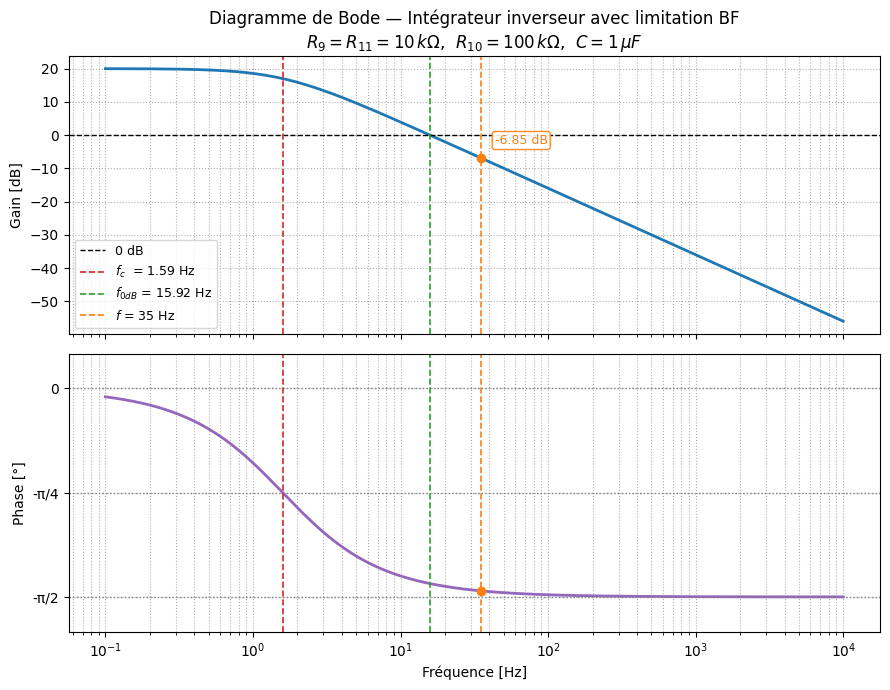

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres du montage intégrateur (annexe 4.4)
# Montage inverseur : H(jw) = -(R10/R9) / (1 + jw*R10*C)
R10 = 100e3   # 100 kΩ
R9  = 10e3    # 10 kΩ
R11 = 10e3    # 10 kΩ (compensation courant de biais)
C   = 1e-6    # 1 µF

# Fréquences
f = np.logspace(-1, 4, 2000)   # 0.1 Hz à 10 kHz
w = 2 * np.pi * f
s = 1j * w

# Fonction de transfert complète (signe − inclus)
H = -(R10 / R9) / (1 + s * R10 * C)

mag_db    = 20 * np.log10(np.abs(H))

# np.angle renvoie dans (-180°, +180°].
# Pour un amplificateur inverseur, la phase réelle est dans (-270°, -180°).
# Correction : on soustrait 360° pour passer de (90°..180°) → (-270°..-180°).
phase_deg = np.angle(H, deg=True) - 360   # ∈ (-270°, -180°)

# Fréquences caractéristiques
fc    = 1 / (2 * np.pi * R10 * C)         # pôle : 1.59 Hz
f0dB  = 1 / (2 * np.pi * R9  * C)         # gain = 0 dB : 15.9 Hz
f_ref = 35.0                              # fréquence utilisée pour le calcul final

H_ref        = -(R10 / R9) / (1 + 1j * 2 * np.pi * f_ref * R10 * C)
gain_ref     = np.abs(H_ref)
gain_ref_db  = 20 * np.log10(gain_ref)
phase_ref_deg = np.angle(H_ref, deg=True) - 360

print(f"f_c    = {fc:.3f} Hz  (pôle, gain -3 dB par rapport au plateau BF)")
print(f"f_0dB  = {f0dB:.3f} Hz  (croisement 0 dB)")
print(f"Fréquence utilisée      : {f_ref:.1f} Hz")
print(f"Gain à 35 Hz            : {gain_ref_db:.2f} dB")
print(f"Gain à 35 Hz (linéaire) : {gain_ref:.4f}")
print(f"Phase à très basse fréq : {phase_deg[0]:.1f}°  (attendu ≈ -180°)")
print(f"Phase à très haute fréq : {phase_deg[-1]:.1f}°  (attendu ≈ -270°)")
print(f"Phase à 35 Hz           : {phase_ref_deg:.1f}°")

# --- Tracé ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Gain
ax1.semilogx(f, mag_db, lw=2, color='tab:blue')
ax1.axhline(0, color='k', linestyle='--', lw=1, label='0 dB')
ax1.axvline(fc,   color='tab:red',   linestyle='--', lw=1.2, label=f'$f_c$  = {fc:.2f} Hz')
ax1.axvline(f0dB, color='tab:green', linestyle='--', lw=1.2, label=f'$f_{{0dB}}$ = {f0dB:.2f} Hz')
ax1.axvline(f_ref, color='tab:orange', linestyle='--', lw=1.2, label=f'$f$ = {f_ref:.0f} Hz')
ax1.plot(f_ref, gain_ref_db, 'o', color='tab:orange')
ax1.annotate(f'{gain_ref_db:.2f} dB',
             xy=(f_ref, gain_ref_db),
             xytext=(10, 10),
             textcoords='offset points',
             color='tab:orange',
             fontsize=9,
             bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='tab:orange', alpha=0.9))
ax1.set_ylabel('Gain [dB]')
ax1.legend(fontsize=9)
ax1.grid(True, which='both', ls=':')
ax1.set_title('Diagramme de Bode — Intégrateur inverseur avec limitation BF\n'
              r'$R_9=R_{11}=10\,k\Omega$,  $R_{10}=100\,k\Omega$,  $C=1\,\mu F$')

# Phase
ax2.semilogx(f, phase_deg, lw=2, color='tab:purple')
ax2.axhline(-180, color='gray', ls=':', lw=1)
ax2.axhline(-225, color='gray', ls=':', lw=1)
ax2.axhline(-270, color='gray', ls=':', lw=1)
ax2.axvline(fc,   color='tab:red',   linestyle='--', lw=1.2)
ax2.axvline(f0dB, color='tab:green', linestyle='--', lw=1.2)
ax2.axvline(f_ref, color='tab:orange', linestyle='--', lw=1.2)
ax2.plot(f_ref, phase_ref_deg, 'o', color='tab:orange')

ax2.set_yticks([-270, -225, -180])
ax2.set_yticklabels(['-π/2', '-π/4', '0'])
ax2.set_ylim(-285, -165)
ax2.set_ylabel('Phase [°]')
ax2.set_xlabel('Fréquence [Hz]')
ax2.grid(True, which='both', ls=':')

fig.tight_layout()
fig.savefig('bode_dernier_circuit.png', dpi=180)
import shutil
shutil.copy('bode_dernier_circuit.png',
            'Mécatro labo1/images/bode_dernier_circuit.png')
plt.show()


## Courbes d'induction du rapport

Cette section régénère les figures `Bfx_theo.png` et `BfI_comp.png` utilisées dans le rapport avec le modèle simplifié
$B_{lat}=\mu_0 N_1 I / \left(3(x+\lambda)\right)$ et ici `lambda = 0 mm`.


<>:98: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:98: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1873109/2595693987.py:98: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title("Erreur relative entre $\mu_r=400$ et $\mu_r \\to \infty$")


39.81266679136406
41.88790204786391


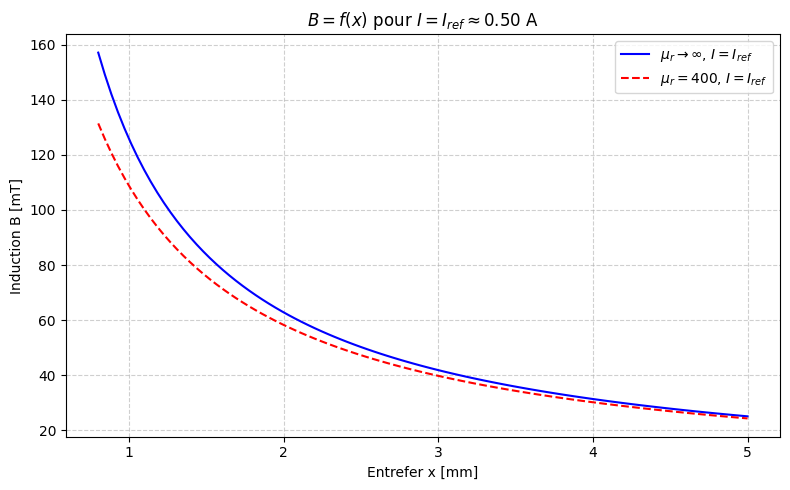

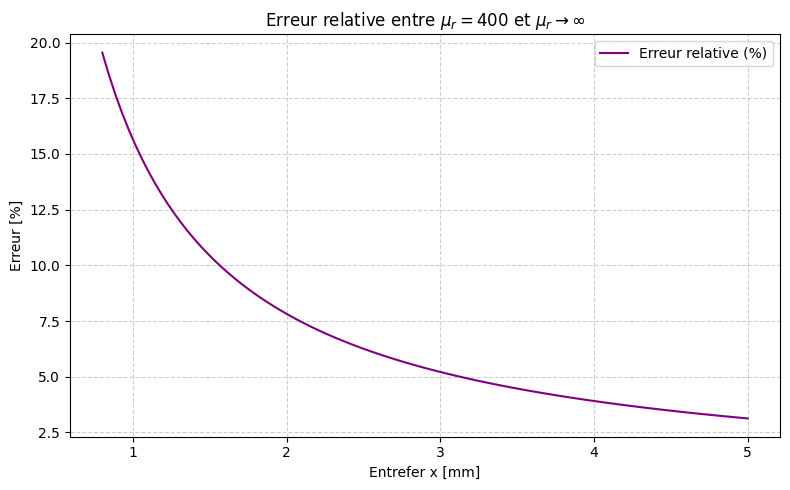

Images générées:
images/Bfx_theo.png
images/BfI_comp.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes
mu0 = 4*np.pi*1e-7
N = 500
I = 0.5

# Sections (m²)
A_yellow = 210e-6
A_blue = 90e-6
A_green = 157.5e-6
A_orange = 210e-6
A_red = 157.5e-6

# Longueurs (m)
l_yellow = 15e-3
l_blue = 23.25e-3
l_green = 15e-3

# Fonction R_eq pour mu_r donné
def R_eq(x_mm, mu_r):
    x = x_mm * 1e-3
    
    # Réluctances fer
    if mu_r == np.inf:
        R_y = 0
        R_b = 0
        R_g = 0
    else:
        R_y = l_yellow / (mu0 * mu_r * A_yellow)
        R_b = l_blue   / (mu0 * mu_r * A_blue)
        R_g = l_green  / (mu0 * mu_r * A_green)
    
    # Réluctances entrefer
    R_o = x / (mu0 * A_orange)
    R_r = x / (mu0 * A_red)
    
    # Circuit équivalent
    R_total = 2*R_y + R_o + 0.5*(2*R_b + 2*R_g + R_r)
    
    return R_total

# Fonction B(x)
def B_field(x_mm, mu_r):
    R = R_eq(x_mm, mu_r)
    Phi = (N * I) / R
    
    # Flux dans branche latérale (divisé par 2)
    Phi_lat = Phi / 2
    
    # Induction dans branche latérale
    B = Phi_lat / A_green
    
    return B * 1e3  # en mT

print(B_field(3, 400))  # Test à x=3mm et mu_r=400
print(B_field(3, np.inf))  # Test à x=3mm et mu_r→∞

# Domaine x
x_vals = np.linspace(0.8, 5, 100)

# Calculs
B_inf = [B_field(x, np.inf) for x in x_vals]
B_400 = [B_field(x, 400) for x in x_vals]

# Calcul erreur relative (%)
B_inf = np.array(B_inf)
B_400 = np.array(B_400)

error_percent = np.abs(B_400 - B_inf) / B_400 * 100

# Plot
plt.figure(figsize=(8,5))

plt.plot(x_vals, B_inf, color='blue', label=r'$\mu_r \to \infty$, $I = I_{ref}$')
plt.plot(x_vals, B_400, 'r--', label=r'$\mu_r = 400$, $I = I_{ref}$')

plt.xlabel('Entrefer x [mm]')
plt.ylabel('Induction B [mT]')
plt.title(r'$B = f(x)$ pour $I = I_{ref} \approx 0.50$ A')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()

plt.savefig('rapport/images/Bfx_theo.png', dpi=300)
plt.show()

# ===== Plot 2 : erreur (%) =====
plt.figure(figsize=(8,5))

plt.plot(x_vals, error_percent, color='purple', label='Erreur relative (%)')

plt.xlabel('Entrefer x [mm]')
plt.ylabel('Erreur [%]')
plt.title("Erreur relative entre $\mu_r=400$ et $\mu_r \\to \infty$")

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig('rapport/images/erreur_relative.png', dpi=300)

plt.show()

print('Images générées:')
print('images/Bfx_theo.png')
print('images/BfI_comp.png')


b = f(i)

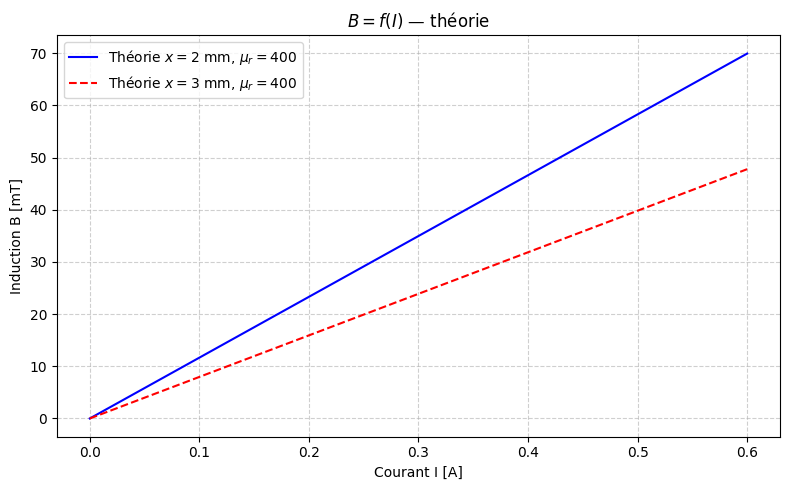

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes
mu0 = 4*np.pi*1e-7
N = 500

# Sections (m²)
A_yellow = 210e-6
A_blue = 90e-6
A_green = 157.5e-6
A_orange = 210e-6
A_red = 157.5e-6

# Longueurs (m)
l_yellow = 15e-3
l_blue = 23.25e-3
l_green = 15e-3

# Fonction réluctance équivalente
def R_eq(x_mm, mu_r):
    x = x_mm * 1e-3
    
    # Fer
    R_y = l_yellow / (mu0 * mu_r * A_yellow)
    R_b = l_blue   / (mu0 * mu_r * A_blue)
    R_g = l_green  / (mu0 * mu_r * A_green)
    
    # Entrefer
    R_o = x / (mu0 * A_orange)
    R_r = x / (mu0 * A_red)
    
    # Circuit équivalent
    return 2*R_y + R_o + 0.5*(2*R_b + 2*R_g + R_r)

# Fonction B(I)
def B_field(I, x_mm, mu_r):
    R = R_eq(x_mm, mu_r)
    Phi = (N * I) / R
    
    # flux branche latérale
    Phi_lat = Phi / 2
    
    # induction
    B = Phi_lat / A_green
    
    return B * 1e3  # en mT

# Courant
I_vals = np.linspace(0, 0.6, 100)

# Calculs
B_x2 = [B_field(I, 2, 400) for I in I_vals]
B_x3 = [B_field(I, 3, 400) for I in I_vals]

# Plot
plt.figure(figsize=(8,5))

plt.plot(I_vals, B_x2, color='blue', label=r'Théorie $x = 2$ mm, $\mu_r = 400$')
plt.plot(I_vals, B_x3, 'r--', label=r'Théorie $x = 3$ mm, $\mu_r = 400$')

plt.xlabel('Courant I [A]')
plt.ylabel('Induction B [mT]')
plt.title(r'$B = f(I)$ — théorie')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig('rapport/images/BfI_comp.png', dpi=300)
plt.show()

In [ ]:
avec mesure

58.27544195401622
39.81266679136406


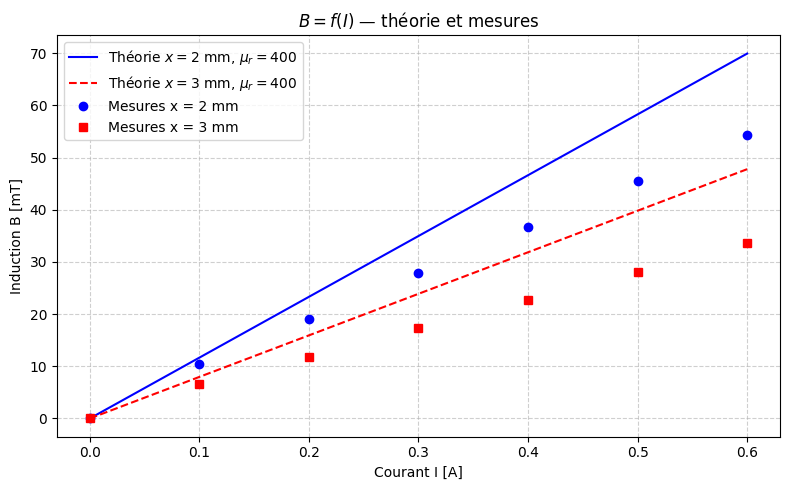

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes
mu0 = 4*np.pi*1e-7
N = 500

# Sections (m²)
A_yellow = 210e-6
A_blue = 90e-6
A_green = 157.5e-6
A_orange = 210e-6
A_red = 157.5e-6

# Longueurs (m)
l_yellow = 15e-3
l_blue = 23.25e-3
l_green = 15e-3

# ----------- MODELE THEORIQUE -----------

def R_eq(x_mm, mu_r):
    x = x_mm * 1e-3
    
    R_y = l_yellow / (mu0 * mu_r * A_yellow)
    R_b = l_blue   / (mu0 * mu_r * A_blue)
    R_g = l_green  / (mu0 * mu_r * A_green)
    
    R_o = x / (mu0 * A_orange)
    R_r = x / (mu0 * A_red)
    
    return 2*R_y + R_o + 0.5*(2*R_b + 2*R_g + R_r)

def B_field(I, x_mm, mu_r):
    R = R_eq(x_mm, mu_r)
    Phi = (N * I) / R
    Phi_lat = Phi / 2
    B = Phi_lat / A_green
    return B * 1e3  # mT

# ----------- DONNEES MESUREES -----------

I_mes = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])

B_mes_x2 = np.array([0, 10.35, 19.14, 27.79, 36.7, 45.6, 54.3])
B_mes_x3 = np.array([0, 6.61, 11.8, 17.3, 22.8, 28.1, 33.7])

# ----------- CALCUL THEORIQUE -----------

I_vals = np.linspace(0, 0.6, 100)

B_x2 = [B_field(I, 2, 400) for I in I_vals]
B_x3 = [B_field(I, 3, 400) for I in I_vals]

# ----------- PLOT -----------
print(B_field(0.500, 2, 400))  # Affiche les 5 premières valeurs pour vérification
print(B_field(0.500, 3, 400))  # Affiche les 5 premières valeurs mesurées pour vérification
plt.figure(figsize=(8,5))

# Théorie
plt.plot(I_vals, B_x2, color='blue', label=r'Théorie $x = 2$ mm, $\mu_r = 400$')
plt.plot(I_vals, B_x3, 'r--', label=r'Théorie $x = 3$ mm, $\mu_r = 400$')

# Mesures
plt.plot(I_mes, B_mes_x2, 'o', color='blue', label='Mesures x = 2 mm')
plt.plot(I_mes, B_mes_x3, 's', color='red', label='Mesures x = 3 mm')

# Labels
plt.xlabel('Courant I [A]')
plt.ylabel('Induction B [mT]')
plt.title(r'$B = f(I)$ — théorie et mesures')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig('rapport/images/BfI_comp-mes.png', dpi=300)
plt.show()

Inductance propre et mutuelle

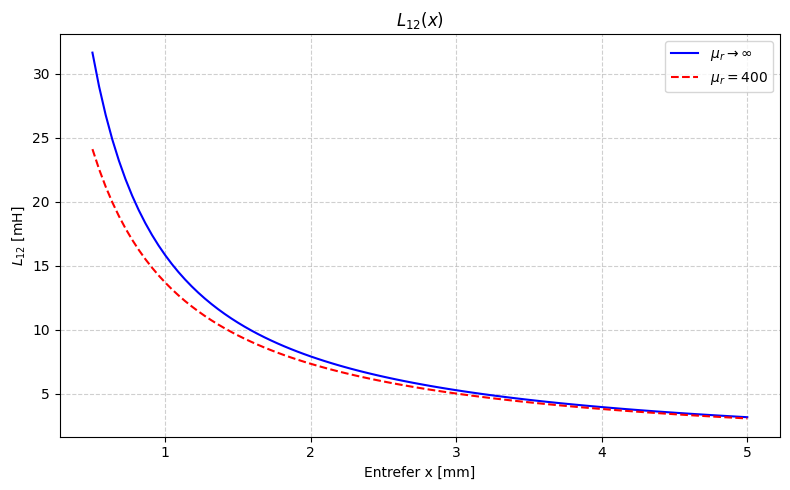

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes
mu0 = 4*np.pi*1e-7

# Spires (à adapter)
N1 = 500
N2 = 200

# Sections (m²)
A_yellow = 210e-6
A_blue = 90e-6
A_green = 157.5e-6
A_orange = 210e-6
A_red = 157.5e-6

# Longueurs (m)
l_yellow = 15e-3
l_blue = 23.25e-3
l_green = 15e-3

# ----------- RELUCTANCE -----------

def R_eq(x_mm, mu_r):
    x = x_mm * 1e-3
    
    if mu_r == np.inf:
        R_y = 0
        R_b = 0
        R_g = 0
    else:
        R_y = l_yellow / (mu0 * mu_r * A_yellow)
        R_b = l_blue   / (mu0 * mu_r * A_blue)
        R_g = l_green  / (mu0 * mu_r * A_green)
    
    # Entrefer
    R_o = x / (mu0 * A_orange)
    R_r = x / (mu0 * A_red)
    
    return 2*R_y + R_o + 0.5*(2*R_b + 2*R_g + R_r)

# ----------- L12 -----------

def L12(x_mm, mu_r):
    return (N1 * N2) / R_eq(x_mm, mu_r)

# Domaine x
x_vals = np.linspace(0.5, 5, 100)

# Calculs
L12_400 = [L12(x, 400) for x in x_vals]
L12_inf = [L12(x, np.inf) for x in x_vals]

# Conversion en mH
L12_400 = np.array(L12_400) * 1e3
L12_inf = np.array(L12_inf) * 1e3

# ----------- PLOT -----------

plt.figure(figsize=(8,5))

plt.plot(x_vals, L12_inf, color='blue', label=r'$\mu_r \to \infty$')
plt.plot(x_vals, L12_400, 'r--', label=r'$\mu_r = 400$')

plt.xlabel('Entrefer x [mm]')
plt.ylabel(r'$L_{12}$ [mH]')
plt.title(r'$L_{12}(x)$')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig('rapport/images/L12.png', dpi=300)
plt.show()